In [1]:
import pglis
import datetime
import matplotlib.dates as mdates
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# initialise
model = pglis.solar_mod()


# helper: date unix timestamp
def dt(year, month, day):
    return datetime.datetime(year, month, day, tzinfo=datetime.timezone.utc).timestamp()

[pglis] SSN updated: 726 points -> /Users/davidpelosi/Desktop/PgLis/pglis/data_products/SSN.csv
[pglis] Dataset is up to date (version https://zenodo.org/records/19971913).


# Flux over time

### Hydrogen over time (as an array)

In [2]:
times = np.linspace(dt(1996, 1, 1), dt(2031, 1, 1), 200, endpoint=True)

# - flux vs time
array_H = model.get_array_flux_vs_time(
    Z=1, Ekn=1000.0, times=times  # Hydrogenx  # MeV/n
)
print(array_H)

[1.14970028 1.16941594 1.20808562 1.23367394 1.24770201 1.25686994
 1.28390648 1.28333273 1.28473134 1.27039042 1.24930751 1.23447996
 1.17841615 1.14767773 1.1149476  1.05907361 0.99492035 0.90253207
 0.80020586 0.73832867 0.67893233 0.63776488 0.6057097  0.52881471
 0.49336001 0.46568754 0.43020532 0.40000876 0.35012404 0.338889
 0.32096397 0.31102606 0.31722721 0.31749682 0.33752276 0.34505346
 0.37466135 0.34926319 0.32928831 0.30887633 0.30366633 0.3026972
 0.30176064 0.31811099 0.34415938 0.38247366 0.43219611 0.45875783
 0.51374145 0.57186829 0.62672221 0.6521396  0.68679781 0.7393971
 0.77297188 0.80698826 0.84289099 0.86780792 0.88618402 0.91736873
 0.94671814 0.97375025 0.98463339 1.01847389 1.04026573 1.04437182
 1.0454579  1.06506925 1.07727433 1.09463558 1.12710781 1.1632275
 1.16724472 1.2140009  1.25653765 1.25750645 1.29347486 1.31716443
 1.31716443 1.3155833  1.29700114 1.21633798 1.15079239 1.12764828
 1.09075715 1.0590768  1.04719144 1.01676551 0.96265391 0.91251099


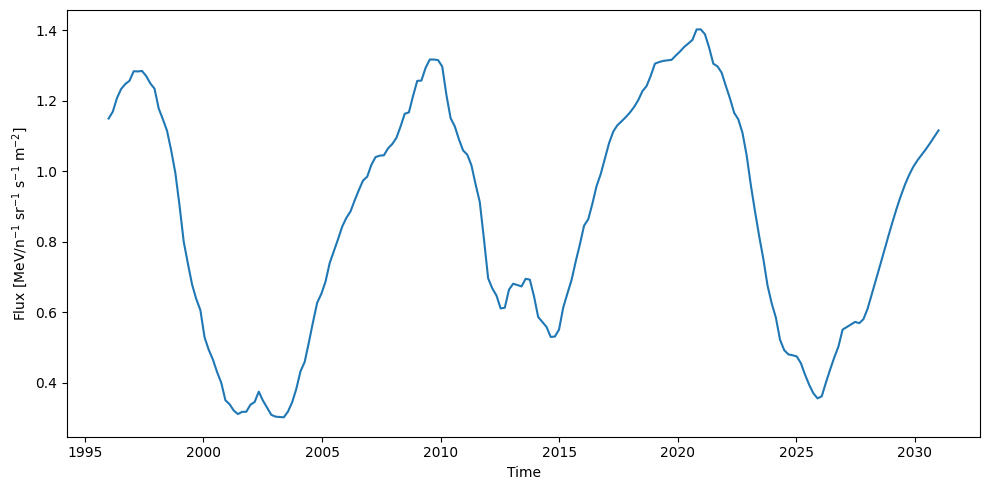

In [3]:
dates = [datetime.datetime.fromtimestamp(t, datetime.UTC) for t in times]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(dates, array_H)

ax.set_xlabel("Time")
ax.set_ylabel(r"Flux [MeV/n$^{-1}$ sr$^{-1}$ s$^{-1}$ m$^{-2}$]")


ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.show()

### Hydrogen over time (as a Pandas Dataframe)

In [4]:
# - flux vs time
df = model.get_dataframe_flux_vs_time(
    Z=1, Ekn=1000.0, t_start=dt(1996, 1, 1), t_end=dt(2031, 1, 1)  # Hydrogen  # MeV/n
)

print(df.head())

     time_unix         datetime_utc  J[MeV/n^(-1) sr^(-1) s^(-1) m^(-2)]
0  820454400.0  1996-01-01T01:00:00                             1.149700
1  823053312.0  1996-01-31T02:55:12                             1.157401
2  825652224.0  1996-03-01T04:50:24                             1.167521
3  828251136.0  1996-03-31T07:45:36                             1.183062
4  830850048.0  1996-04-30T09:40:48                             1.203942


### Lithium over time (as a Pandas Dataframe)

In [5]:
# - flux vs time
df2 = model.get_dataframe_flux_vs_time(
    Z=2, Ekn=1000.0, t_start=dt(1996, 1, 1), t_end=dt(2031, 1, 1)  # Hydrogen  # MeV/n
)

### Plot of Hydrogen & Lithium over time

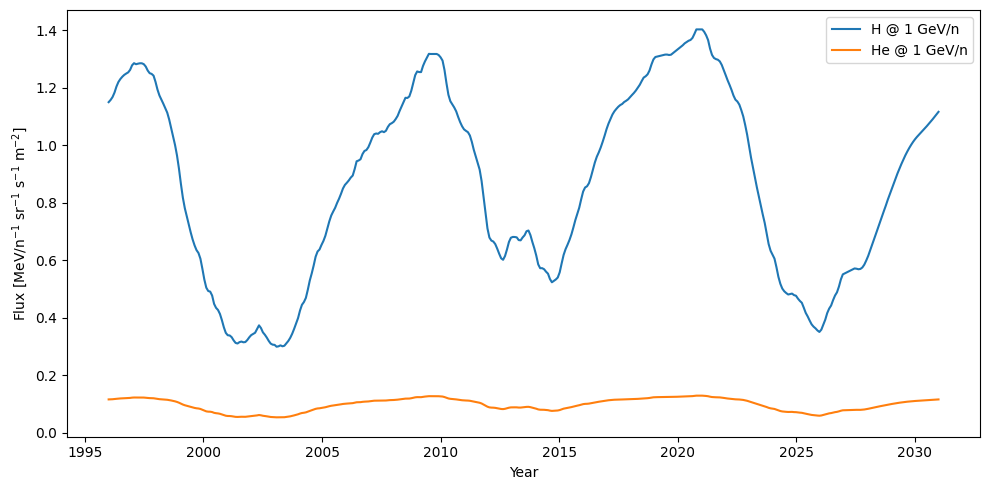

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))


t1 = pd.to_datetime(df["time_unix"], unit="s", utc=True)
t2 = pd.to_datetime(df2["time_unix"], unit="s", utc=True)

ax.plot(t1, df["J[MeV/n^(-1) sr^(-1) s^(-1) m^(-2)]"], label="H @ 1 GeV/n")

ax.plot(t2, df2["J[MeV/n^(-1) sr^(-1) s^(-1) m^(-2)]"], label="He @ 1 GeV/n")

ax.set_xlabel("Year")
ax.set_ylabel(r"Flux [MeV/n$^{-1}$ sr$^{-1}$ s$^{-1}$ m$^{-2}$]")


ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.legend()

plt.tight_layout()
plt.show()

### Hydrogen flux spectrum for a given time (2001/06/01)

In [7]:
import pglis, datetime

model = pglis.solar_mod()

t = datetime.datetime(2001, 6, 1).timestamp()

df = model.get_dataframe_flux_vs_energy(Z=1, time=t)

df.head()

,Ekn[MeV/n],J[MeV/n^(-1) sr^(-1) s^(-1) m^(-2)]
0,10.000000,0.017637
1,10.473709,0.018321
2,10.969858,0.019032
3,11.489510,0.019770
4,12.033778,0.020537


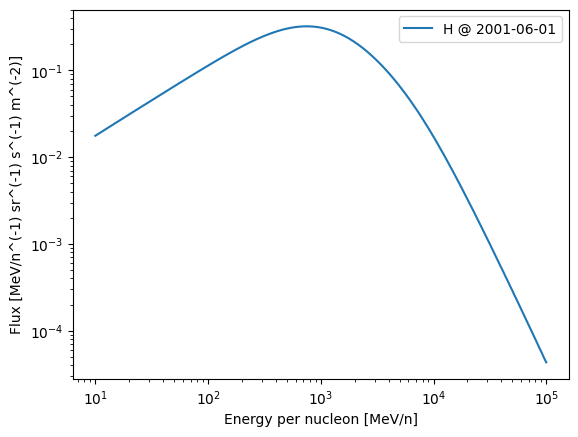

In [8]:
# plot
fig, ax = plt.subplots()
ax.plot(
    df["Ekn[MeV/n]"], df["J[MeV/n^(-1) sr^(-1) s^(-1) m^(-2)]"], label="H @ 2001-06-01"
)
ax.set_xlabel("Energy per nucleon [MeV/n]")

# log scale
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylabel("Flux [MeV/n^(-1) sr^(-1) s^(-1) m^(-2)]")
ax.legend()

plt.show()